In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load and Clean Data
df = pd.read_csv('Online Retail.csv')
df.head()





,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 8:26,3.39,17850.0,United Kingdom


In [5]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
63458,541570,21929,JUMBO BAG PINK VINTAGE PAISLEY,100,19/01/11 12:34,1.65,14646.0,Netherlands
63459,541570,22254,FELT TOADSTOOL LARGE,192,19/01/11 12:34,1.06,14646.0,Netherlands
63460,541570,85049C,ROMANTIC PINKS RIBBONS,144,19/01/11 12:34,1.06,14646.0,Netherlands
63461,541570,22328,ROUND SNACK BOXES SET OF 4 FRUITS,192,19/01/11 12:34,2.55,14646.0,Netherlands


In [3]:
df.shape
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [8]:
df.isnull().sum()


,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [9]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 38435 entries, 0 to 63462
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    38435 non-null  object 
 1   StockCode    38435 non-null  object 
 2   Description  38435 non-null  object 
 3   Quantity     38435 non-null  int64  
 4   InvoiceDate  38435 non-null  object 
 5   UnitPrice    38435 non-null  float64
 6   CustomerID   38435 non-null  float64
 7   Country      38435 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.6+ MB


,Quantity,UnitPrice,CustomerID
count,38435.000000,38435.000000,38435.000000
mean,12.110394,3.245204,15369.090516
std,539.780297,8.354162,1771.480403
min,-74215.000000,0.000000,12346.000000
25%,2.000000,1.250000,13959.000000
50%,4.000000,2.100000,15351.000000
75%,12.000000,3.750000,17017.000000
max,74215.000000,1126.000000,18283.000000


In [7]:
# 1. Filter the dataset to show only rows where Quantity is less than zero
negative_quantities = df[df['Quantity'] < 0]

# 2. Sort the values from lowest (most negative) to highest to easily spot the massive outliers
negative_quantities = negative_quantities.sort_values(by='Quantity')

# 3. Display the top 20 largest returns/cancellations
print("Top 20 Largest Negative Quantities (Returns/Cancellations):")
print(negative_quantities[['InvoiceNo', 'CustomerID', 'Description', 'Quantity', 'UnitPrice']].head(20))

Top 20 Largest Negative Quantities (Returns/Cancellations):
      InvoiceNo  CustomerID                          Description  Quantity  \
61624   C541433     12346.0       MEDIUM CERAMIC TOP STORAGE JAR    -74215   
4287    C536757     15838.0  ROTATING SILVER ANGELS T-LIGHT HLDR     -9360   
34292   C539329     16013.0   WHITE HANGING HEART T-LIGHT HOLDER      -500   
34291   C539329     16013.0              GOLD MINI TAPE MEASURE       -300   
30078   C538847     17404.0      SET OF 3 BABUSHKA STACKING TINS      -240   
4854    C536812     16546.0    HEART WOODEN CHRISTMAS DECORATION      -192   
4857    C536812     16546.0            CARD HOLDER GINGHAM HEART      -192   
43663   C540109     17389.0  BLUE CHARLIE+LOLA PERSONAL DOORSIGN      -150   
4856    C536812     16546.0              CHRISTMAS GINGHAM HEART      -144   
4855    C536812     16546.0               CHRISTMAS GINGHAM STAR      -144   
21699   C538110     17307.0       STRAWBERRY CERAMIC TRINKET BOX      -144   
2520

In [11]:

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'].astype(str), errors='coerce')
df = df.dropna(subset=['InvoiceDate'])
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['TotalSales'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.to_period('M')
df['Month_Number'] = df['InvoiceDate'].dt.month
df

/tmp/ipykernel_4538/145963255.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'].astype(str), errors='coerce')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Month,Month_Number
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-01,1
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-01,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-01,1
...,...,...,...,...,...,...,...,...,...,...,...
63458,541570,21929,JUMBO BAG PINK VINTAGE PAISLEY,100,2011-01-19 12:34:00,1.65,14646.0,Netherlands,165.00,2011-01,1
63459,541570,22254,FELT TOADSTOOL LARGE,192,2011-01-19 12:34:00,1.06,14646.0,Netherlands,203.52,2011-01,1
63460,541570,85049C,ROMANTIC PINKS RIBBONS,144,2011-01-19 12:34:00,1.06,14646.0,Netherlands,152.64,2011-01,1
63461,541570,22328,ROUND SNACK BOXES SET OF 4 FRUITS,192,2011-01-19 12:34:00,2.55,14646.0,Netherlands,489.60,2011-01,1


In [ ]:
monthly_sales = df.groupby('Month')['TotalSales'].sum()
top_products = df.groupby('Description')['Quantity'].sum().nlargest(10)
country_sales = df.groupby('Country')['TotalSales'].sum().nlargest(5)

/tmp/ipykernel_4538/58411932.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], data=top_products, y='Description', x='Quantity', palette='viridis')
/tmp/ipykernel_4538/58411932.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1, 0], data=top_regions, x='Country', y='Revenue', palette='magma')


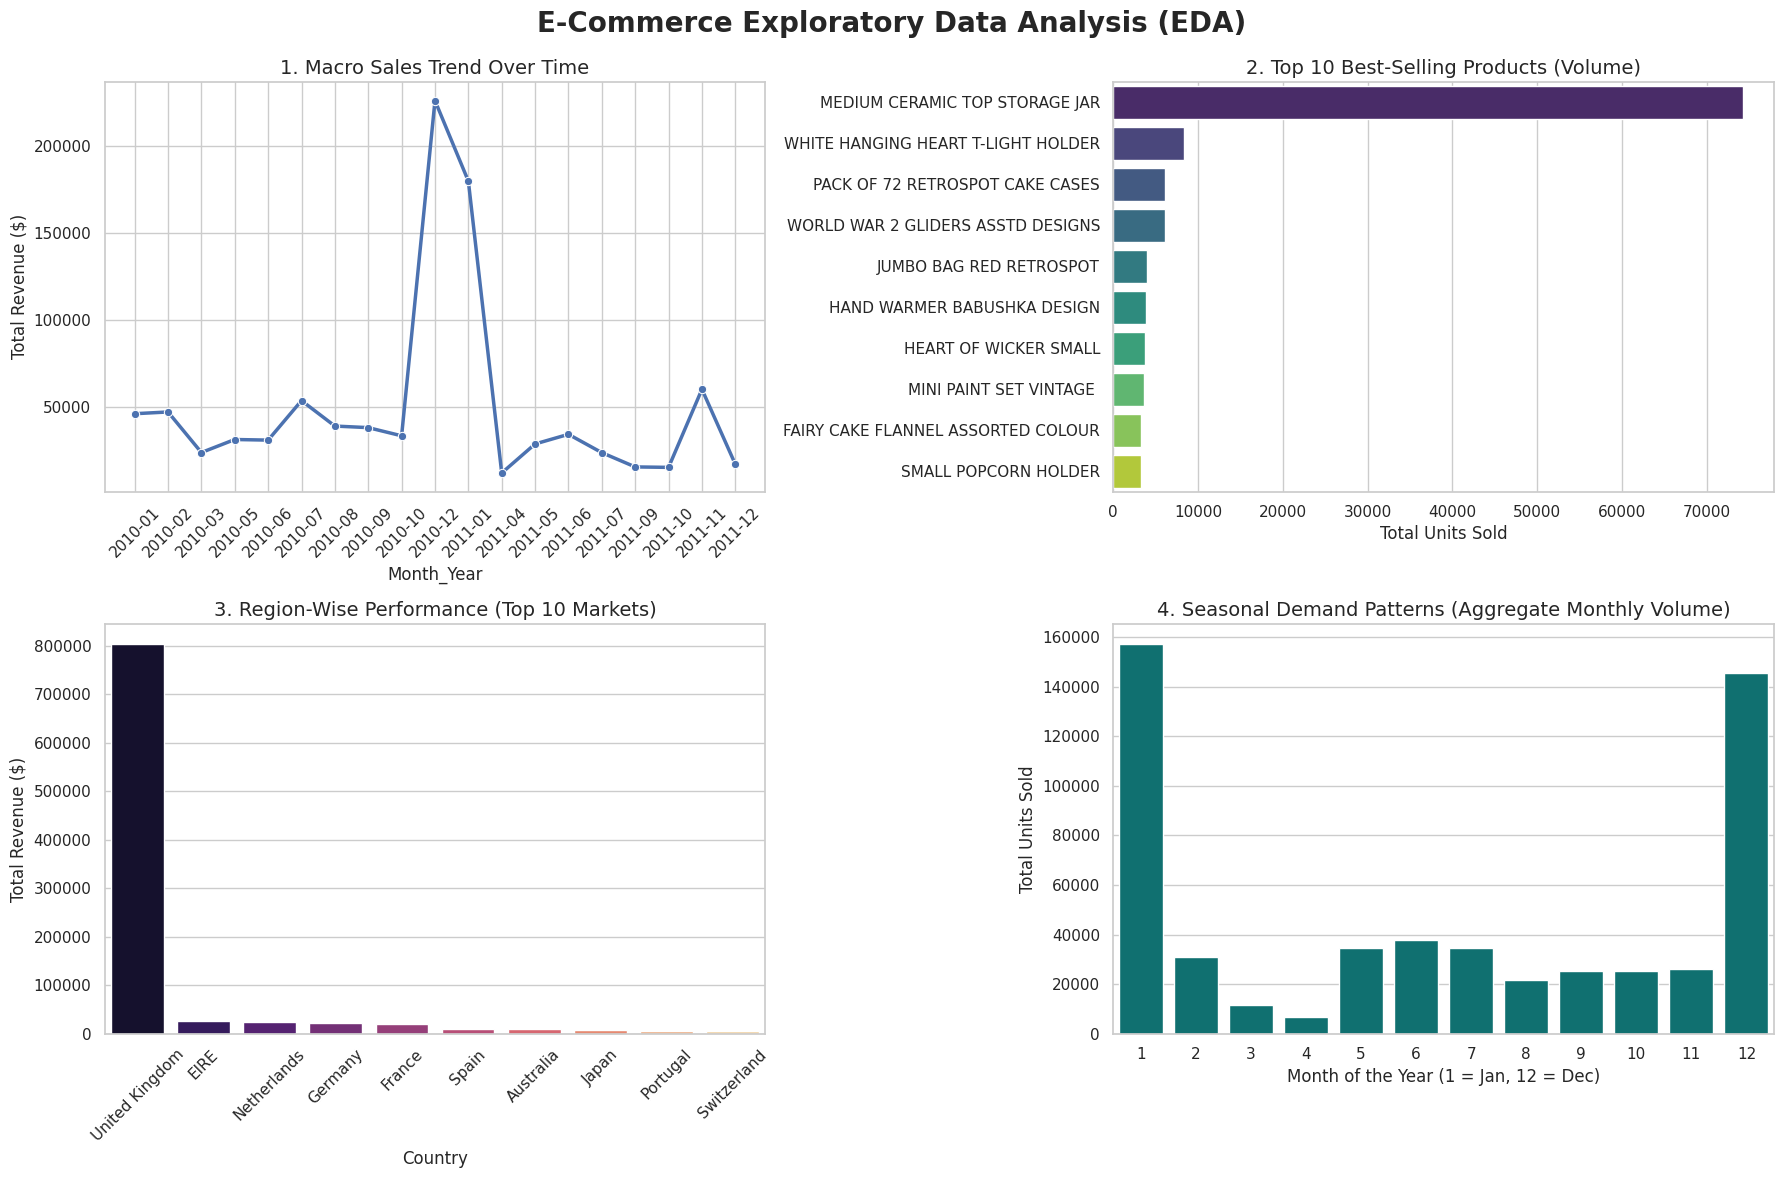

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature Engineering for EDA (Calculating Revenue)
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Month_Year'] = df['InvoiceDate'].dt.to_period('M')
df['Month'] = df['InvoiceDate'].dt.month

# Set global visual style for the portfolio
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('E-Commerce Exploratory Data Analysis (EDA)', fontsize=20, fontweight='bold')

# 2. Sales Trend Over Time (Top Left)
sales_trend = df.groupby('Month_Year')['Revenue'].sum().reset_index()
sales_trend['Month_Year'] = sales_trend['Month_Year'].astype(str)
sns.lineplot(ax=axes[0, 0], data=sales_trend, x='Month_Year', y='Revenue', marker='o', color='b', linewidth=2.5)
axes[0, 0].set_title('1. Macro Sales Trend Over Time', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_ylabel('Total Revenue ($)')

# 3. Top-Selling Products (Top Right)
top_products = df.groupby('Description')['Quantity'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[0, 1], data=top_products, y='Description', x='Quantity', palette='viridis')
axes[0, 1].set_title('2. Top 10 Best-Selling Products (Volume)', fontsize=14)
axes[0, 1].set_xlabel('Total Units Sold')
axes[0, 1].set_ylabel('')

# 4. Region-Wise Performance (Bottom Left)
# Excluding UK to see international spread, or keep all. We'll show top 10 regions.
top_regions = df.groupby('Country')['Revenue'].sum().nlargest(10).reset_index()
sns.barplot(ax=axes[1, 0], data=top_regions, x='Country', y='Revenue', palette='magma')
axes[1, 0].set_title('3. Region-Wise Performance (Top 10 Markets)', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylabel('Total Revenue ($)')

# 5. Seasonal Demand Patterns (Bottom Right)
seasonal_trend = df.groupby('Month')['Quantity'].sum().reset_index()
sns.barplot(ax=axes[1, 1], data=seasonal_trend, x='Month', y='Quantity', color='teal')
axes[1, 1].set_title('4. Seasonal Demand Patterns (Aggregate Monthly Volume)', fontsize=14)
axes[1, 1].set_xlabel('Month of the Year (1 = Jan, 12 = Dec)')
axes[1, 1].set_ylabel('Total Units Sold')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [13]:
# Feature Engineering for ML
# Aggregate data at the Product-Month level
demand_df = df.groupby(['Description', 'Month']).agg({'Quantity': 'sum'}).reset_index()
demand_df['Month'] = demand_df['Month'].astype(str)
demand_df.head()



,Description,Month,Quantity
0,4 PURPLE FLOCK DINNER CANDLES,1,2
1,4 PURPLE FLOCK DINNER CANDLES,5,13
2,OVAL WALL MIRROR DIAMANTE,1,3
3,OVAL WALL MIRROR DIAMANTE,8,1
4,OVAL WALL MIRROR DIAMANTE,12,8


In [14]:
# Create lag features (previous month's demand) to predict current demand
demand_df['Lag_1_Quantity'] = demand_df.groupby('Description')['Quantity'].shift(1)
demand_df.dropna(inplace=True)
demand_df.head()

,Description,Month,Quantity,Lag_1_Quantity
1,4 PURPLE FLOCK DINNER CANDLES,5,13,2.0
3,OVAL WALL MIRROR DIAMANTE,8,1,3.0
4,OVAL WALL MIRROR DIAMANTE,12,8,1.0
6,SET 2 TEA TOWELS I LOVE LONDON,2,2,264.0
7,SET 2 TEA TOWELS I LOVE LONDON,3,5,2.0


In [15]:


X = demand_df[['Lag_1_Quantity']]
y = demand_df['Quantity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Evaluation
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_preds)}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds)}")

Linear Regression MAE: 40.90047767300985
Random Forest MAE: 41.5506829722362


In [16]:
from xgboost import XGBRegressor
demand_df = df.groupby(['Description', pd.Grouper(key='InvoiceDate', freq='ME')])['Quantity'].sum().reset_index()
demand_df['Month'] = demand_df['InvoiceDate'].dt.month

demand_df['Lag_1'] = demand_df.groupby('Description')['Quantity'].shift(1)
demand_df['Lag_2'] = demand_df.groupby('Description')['Quantity'].shift(2)
demand_df['Lag_3'] = demand_df.groupby('Description')['Quantity'].shift(3)
demand_df['Rolling_Mean_3'] = demand_df.groupby('Description')['Lag_1'].transform(lambda x: x.rolling(3, min_periods=1).mean())

demand_df = demand_df.dropna()

upper_limit = demand_df['Quantity'].quantile(0.99)
demand_df = demand_df[demand_df['Quantity'] <= upper_limit]

X = demand_df[['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month']]
y = demand_df['Quantity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
mae = mean_absolute_error(y_test, xgb_preds)

print(f"XGBoost MAE: {mae}")

XGBoost MAE: 24.975635528564453


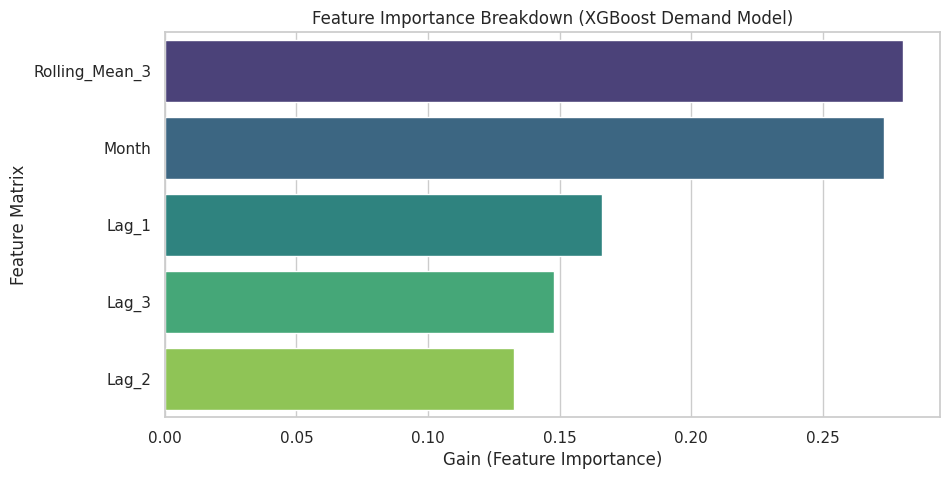

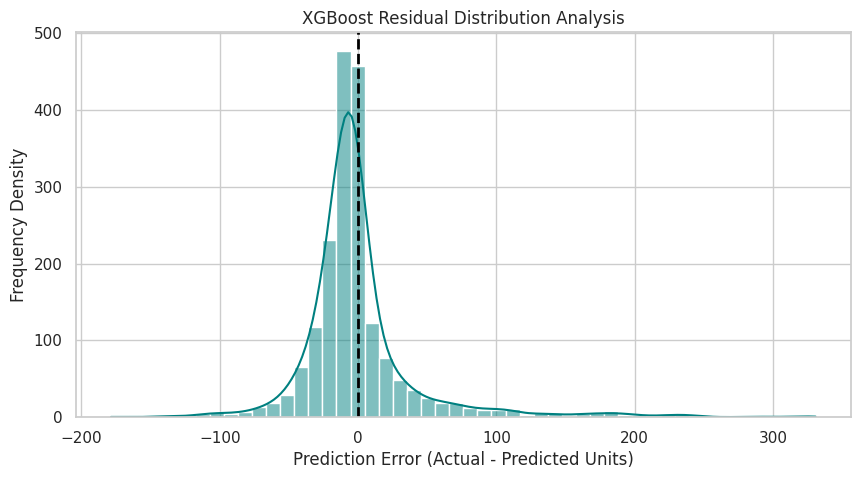

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Feature Importance Analytics for XGBoost (updated from Random Forest)
# Reconstruct the feature list based on your input matrix for XGBoost
feature_names = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month']

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=xgb_importance_df, palette='viridis', legend=False)
plt.title('Feature Importance Breakdown (XGBoost Demand Model)')
plt.xlabel('Gain (Feature Importance)')
plt.ylabel('Feature Matrix')
plt.show()

# 2. Residual Analysis (Prediction Error Distribution) for XGBoost (updated from Random Forest)
# Residuals = Actual Demand - Predicted Demand
xgb_residuals = y_test - xgb_preds

plt.figure(figsize=(10, 5))
sns.histplot(xgb_residuals, kde=True, color='teal', bins=50)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('XGBoost Residual Distribution Analysis')
plt.xlabel('Prediction Error (Actual - Predicted Units)')
plt.ylabel('Frequency Density')
plt.show()

In [18]:
X_predict = demand_df[['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month']]
demand_df['Predicted_Demand'] = xgb.predict(X_predict)
demand_df['Predicted_Demand'] = demand_df['Predicted_Demand'].round().astype(int)

# The 'Month' column in the current demand_df is an integer (1-12).
# So, latest_month should be the maximum month number.
latest_month_num = demand_df['Month'].max()
forecast_df = demand_df[demand_df['Month'] == latest_month_num].sort_values(by='Predicted_Demand', ascending=False)

print("\n========================================================")
print("             DEMAND FORECASTING OUTPUT")
print("========================================================")
print(forecast_df[['Description', 'Lag_1', 'Predicted_Demand']].head(15).to_string(index=False))

print("\n========================================================")
print("      BUSINESS INSIGHTS FOR INVENTORY OPTIMIZATION")
print("========================================================")
print("1. High-Priority Restocking:")
top_item_1 = forecast_df.iloc[0]['Description']
top_item_2 = forecast_df.iloc[1]['Description']
print(f"   - Immediately secure inventory for '{top_item_1}' and '{top_item_2}'.")
print("   - Allocate premium warehouse space for these fast-moving goods to reduce picking time.")
print("\n2. Seasonal Capacity Planning:")
print("   - Align logistics and warehouse labor with the peak transaction months identified in the seasonal EDA chart.")
print("   - Draft supplier contracts 6 weeks prior to anticipated seasonal surges to avoid stockouts.")
print("\n3. Capital Allocation:")
print("   - Halt or reduce procurement for items in the bottom 10% of the Predicted_Demand array.")
print("   - Liquidate dead stock identified by consistently zero or negative growth in Lag_1 to free up working capital.")


             DEMAND FORECASTING OUTPUT
                        Description  Lag_1  Predicted_Demand
     STRAWBERRY CERAMIC TRINKET BOX  194.0               299
 MULTI COLOUR SILVER T-LIGHT HOLDER   24.0               282
         MAGIC DRAWING SLATE PURDEY   24.0               261
        ANGEL DECORATION 3 BUTTONS    48.0               247
          PACK OF 6 BIRDY GIFT TAGS   24.0               233
    PINK HEART SHAPE EGG FRYING PAN  144.0               221
SET OF 20 VINTAGE CHRISTMAS NAPKINS   36.0               209
        WOODEN FRAME ANTIQUE WHITE    15.0               203
      GINGERBREAD MAN COOKIE CUTTER   37.0               201
   AGED GLASS SILVER T-LIGHT HOLDER  252.0               200
     JUMBO  BAG BAROQUE BLACK WHITE  110.0               200
     PACK OF 12 TRADITIONAL CRAYONS   27.0               186
   PACK OF 12 PINK POLKADOT TISSUES  120.0               181
      WHITE SKULL HOT WATER BOTTLE    34.0               180
          PLASTERS IN TIN STRONGMAN   52.0   